# Low correlation, $S_{1/2}$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
import sys
from scipy.special import legendre
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
sys.path.insert(1, '../../scripts')
import CMBanom

In [31]:
# Parameters
Nside  = 128
method = "summation"
mus    = np.linspace(-0.9, 1, 20)
mu_index  = 14
print(mus[mu_index])
load_stats_from_cluster = False

if load_stats_from_cluster: Nsims = 100000
else:                       Nsims = 1000

0.4999999999999999


In [3]:
# Directories
sims_dir = '../../data/sims/sims_1k/'
real_dir = "../../data/real/"
stats_dir = "../../data/stats/"

# Planck maps  
#names_Planck  = [  "commander_nside_128",        "nilc_nside_128",      "sevem_nside_128",   "smica_nside_128", "v9_70GHz_nside_128", "v9_94GHz_nside_128", "v9_100GHz_nside_128", "v9_143GHz_nside_128"]
#names_Planck  = [  "commander_nside_128",        "nilc_nside_128",      "sevem_nside_128",   "smica_nside_128", "v9_70GHz_LCDMdebias",   "v9_94GHz_LCDMdebias", "v9_100GHz_LCDMdebias", "v9_143GHz_LCDMdebias"]
names_Planck  = [  "commander_nside_128",        "nilc_nside_128",      "sevem_nside_128",   "smica_nside_128", "v9_70GHz_POBSdebias",   "v9_94GHz_POBSdebias", "v9_100GHz_POBSdebias", "v9_143GHz_POBSdebias"]
labels_Planck = [r"$\mathrm{Commander}$", r"$\mathrm{NILC}$", r"$\mathrm{SEVEM}$", r"$\mathrm{SMICA}$", r"$70\, \mathrm{GHz}$", r"$94\, \mathrm{GHz}$", r"$100\, \mathrm{GHz}$", r"$143\, \mathrm{GHz}$"]

colors_Planck = [  "tab:red", "teal",  "navy",  "gold", "tab:red",    "teal",   "navy",   "gold"]
lss_Planck    = [       "--",   "--",    "--",    "--",       "-",       "-",      "-",      "-"]
color_qml     = "green"
label_qml     = r"$\mathrm{Public\ QML-}C_\ell$"
index_Planck  = 0
index_Hayley  = 6
Nmaps = len(names_Planck)

# Masks
names_mask  = [              "fullsky",                "stdmask",                  "commask"]
labels_mask = [r"$\mathrm{Full\ sky}$", r"$\mathrm{Std.\ mask}$", r"$\mathrm{Common\ mask}$"]
colors_mask = [             "tab:blue",                   "navy",                "firebrick"]
Nmasks = len(names_mask)

# Cls
fn_cl_theory = "../../data/real/COM_PowerSpect_CMB-base-plikHM-TTTEEE-lowl-lowE-lensing-minimum-theory_R3.01.txt"
fn_cl_qml    = "../../data/real/COM_PowerSpect_CMB-TT-full_R3.01.txt"

In [4]:
# Font
plt.rc('font',**{'family':'Helvetica','size':20})
plt.rc('text', usetex=True)
font = {'family':'Helvetica',
        'color' : 'black',
        'size'  :  20}

In [5]:
# Same l-range for all Cls
lmax = 384
ll = np.arange(lmax)

In [6]:
# Load Planck Cl (begins with l=0) - *no* window fcts. correction, shape: (Nmasks, Nmaps, lmax)
cl_wf = CMBanom.get_cl_wf_factor(Nside)
cl_Planck = np.array([[np.loadtxt(real_dir+"cl_"+names_Planck[n]+"_"+names_mask[m]+".txt").T[1] for n in range(Nmaps)] for m in range(Nmasks)])

# Compute corr from Cls
theta, cos_theta = np.loadtxt(real_dir+"corr_"+names_Planck[0]+"_"+names_mask[0]+".txt").T[:2]
corr_Planck = np.array([[CMBanom.corr_from_cl(theta, cl_Planck[m][n], lmax=lmax) for n in range(Nmaps)] for m in range(Nmasks)])

/Users/lherold/Applications/anaconda3/lib/python3.7/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/Users/lherold/Applications/anaconda3/lib/python3.7/site-packages/scipy/special/orthogonal.py:2131: RuntimeWarning: overflow encountered in double_scalars
  kn = _gam(2 * n + 1) / _gam(n + 1)**2 / 2.0**n
/Users/lherold/Applications/anaconda3/lib/python3.7/site-packages/scipy/special/orthogonal.py:2131: RuntimeWarning: invalid value encountered in double_scalars
  kn = _gam(2 * n + 1) / _gam(n + 1)**2 / 2.0**n


In [7]:
# Load theory Cl used to generate (begins with l=2)
dl_theory = np.append(np.zeros(2), np.loadtxt(fn_cl_theory, skiprows=1).T[1])[:lmax]
corr_theory = CMBanom.corr_from_cl(theta, dl_theory[2:]/(ll[2:]*(ll[2:]+1)/(2*np.pi)))

In [8]:
# Load QML Cl's (begins with l=2)
dl_qml = np.loadtxt(fn_cl_qml).T[1][:lmax-2]
cl_qml = np.append(np.zeros(2), dl_qml/ll[2:]/(1+ll[2:])*2*np.pi)

# Compute C(theta) from QML Cl's
corr_qml = CMBanom.corr_from_cl(theta, cl_qml)

In [9]:
# Get sim envelope
if load_stats_from_cluster:
    mean_corrs = np.array([np.loadtxt(stats_dir+"corr_mean_perc_"+names_mask[m]+".npy")[0] for m in range(Nmasks)])
    perc_68_lower = np.array([np.loadtxt(stats_dir+"corr_mean_perc_"+names_mask[m]+".npy")[1] for m in range(Nmasks)])
    perc_68_upper = np.array([np.loadtxt(stats_dir+"corr_mean_perc_"+names_mask[m]+".npy")[2] for m in range(Nmasks)])
    perc_95_lower = np.array([np.loadtxt(stats_dir+"corr_mean_perc_"+names_mask[m]+".npy")[3] for m in range(Nmasks)])
    perc_95_upper = np.array([np.loadtxt(stats_dir+"corr_mean_perc_"+names_mask[m]+".npy")[4] for m in range(Nmasks)])
else: 
    cls,corrs = np.zeros((Nmasks, Nsims, lmax)), np.zeros((Nmasks, Nsims, lmax))
    for m in range(Nmasks):
        corrs[m] = CMBanom.load_corrs(sims_dir, names_mask[m], Nsims)[2]
        cls[m]   = CMBanom.load_cls(sims_dir, names_mask[m], Nsims, cl_wf)
    mean_corrs = np.mean(corrs, axis=1)
    std_corrs = np.std(corrs, axis=1)
    perc_68_lower = np.percentile(corrs, (100-68.27)/2, axis=1)
    perc_68_upper = np.percentile(corrs, 68.27+(100-68.27)/2, axis=1)
    perc_95_lower = np.percentile(corrs, (100-95.45)/2, axis=1)
    perc_95_upper = np.percentile(corrs, 95.45+(100-95.45)/2, axis=1)

# Plot $C_\ell$'s

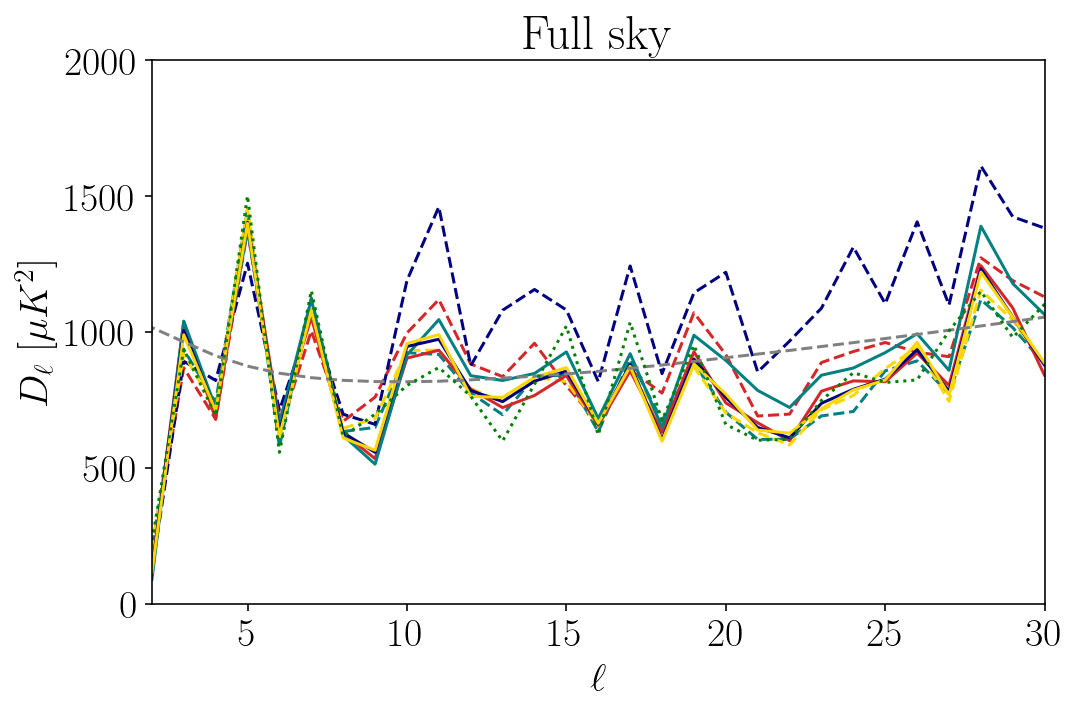

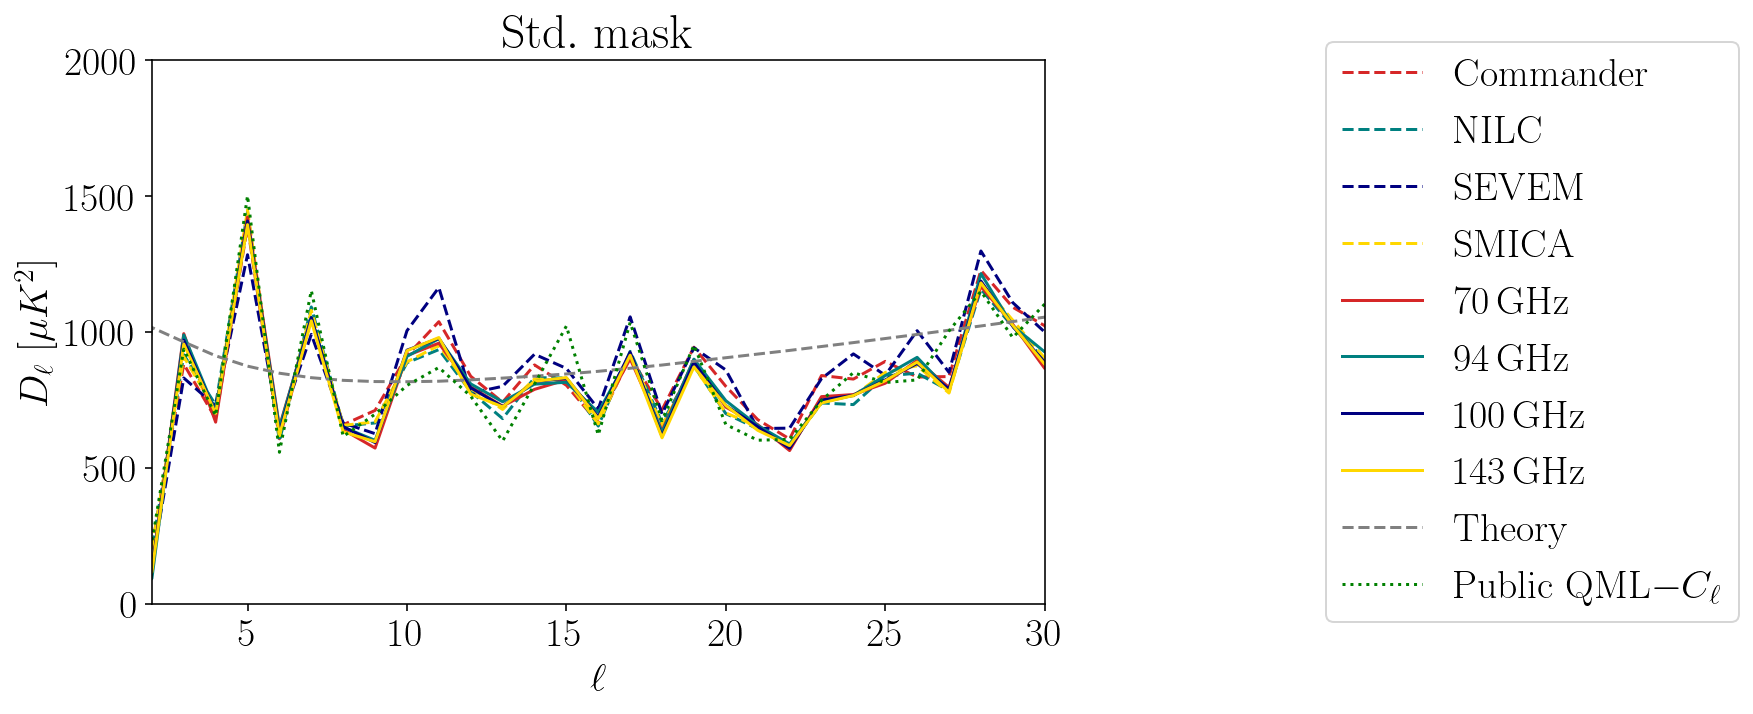

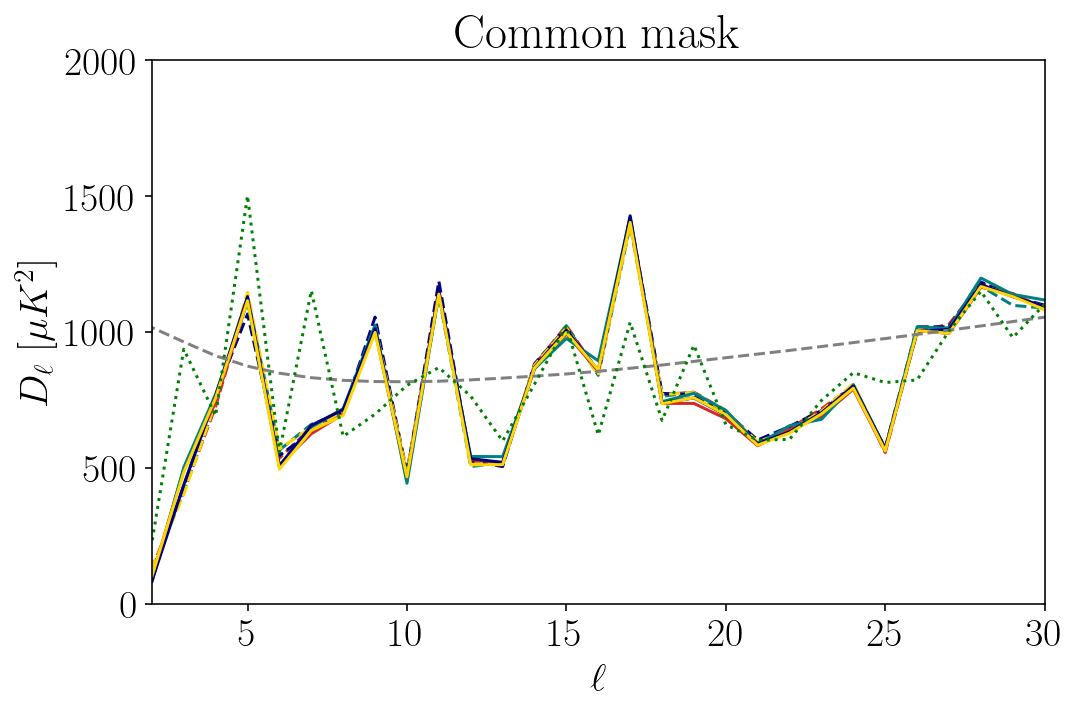

In [10]:
for m in range(Nmasks):
    fig = plt.figure(figsize=(8, 5))
    for n in range(Nmaps): plt.plot(ll, ll*(ll+1)*cl_Planck[m][n]/(2*np.pi), label=labels_Planck[n], color=colors_Planck[n], ls=lss_Planck[n])
    plt.plot(ll, dl_theory, label=r"$\mathrm{Theory}$", color="grey", ls="--")
    plt.plot(ll, ll*(ll+1)*cl_qml/(2*np.pi), label=label_qml, color=color_qml, ls=":")
       
    plt.ylabel(r"$D_\ell\ [\mu K^2]$")
    plt.xlabel(r"$\ell$")
    plt.xlim(2,30)
    plt.ylim(0,2000)
    plt.title(labels_mask[m])
    #plt.legend(loc="lower right")
    if m==1: plt.legend(loc='center right', bbox_to_anchor=(1.8, 0.5))
    plt.savefig(f"Cl_{names_mask[m]}.pdf", format="PDF")
    plt.show()

## Plot $C(\theta)$

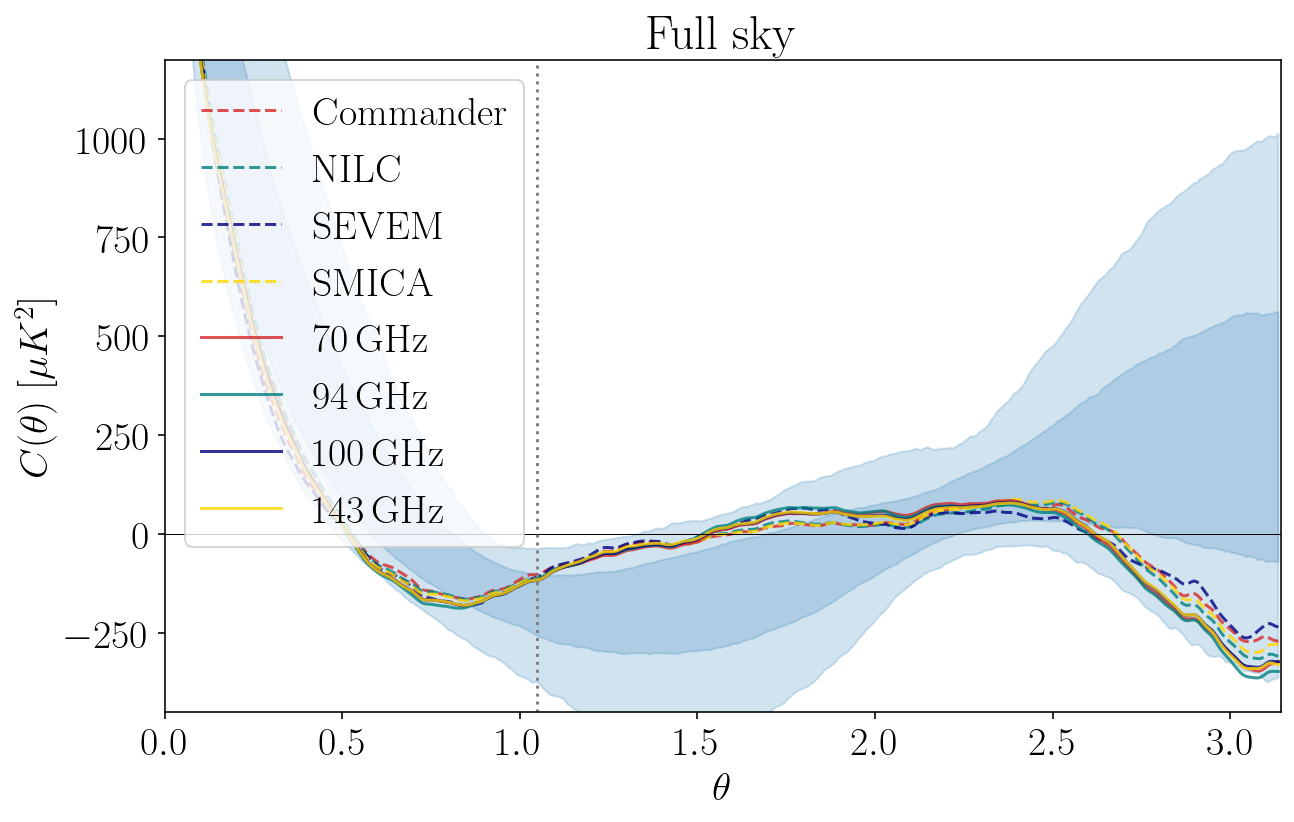

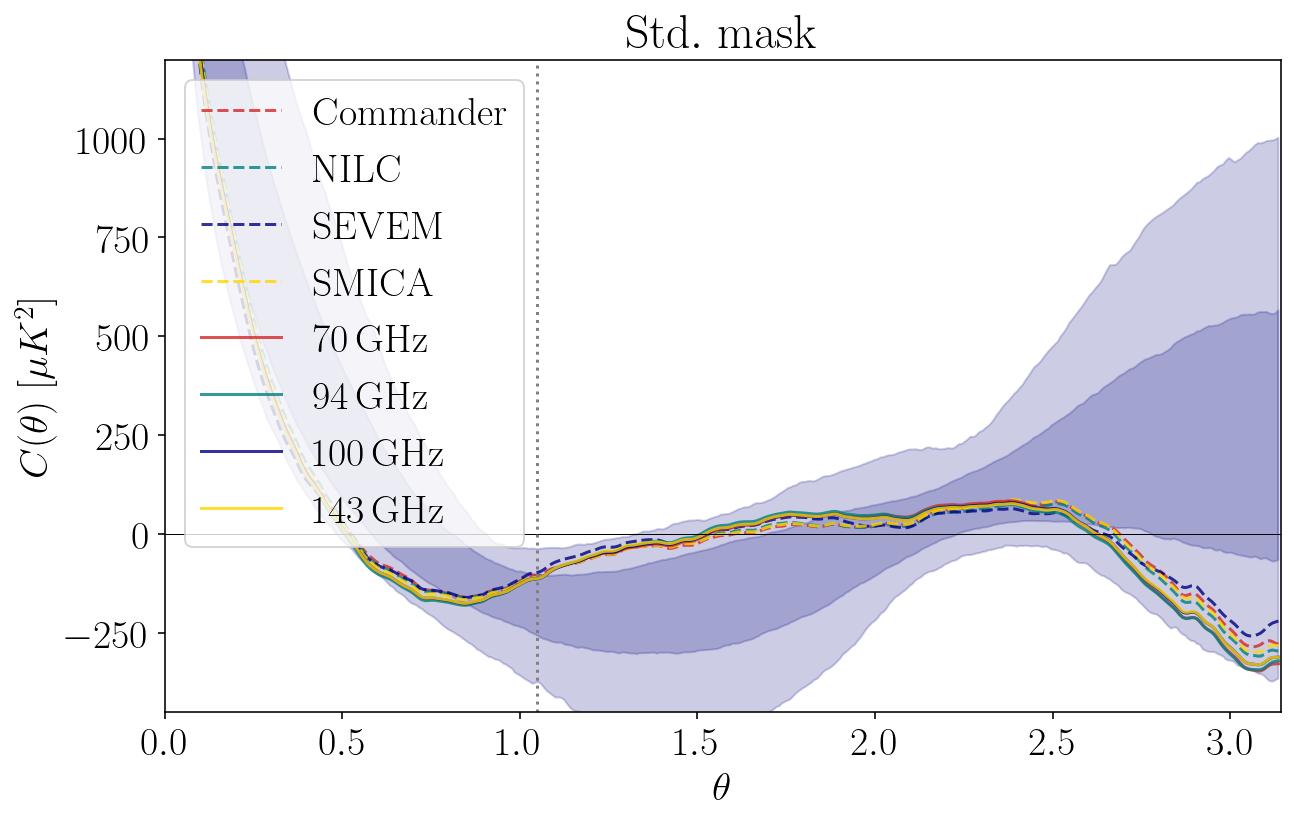

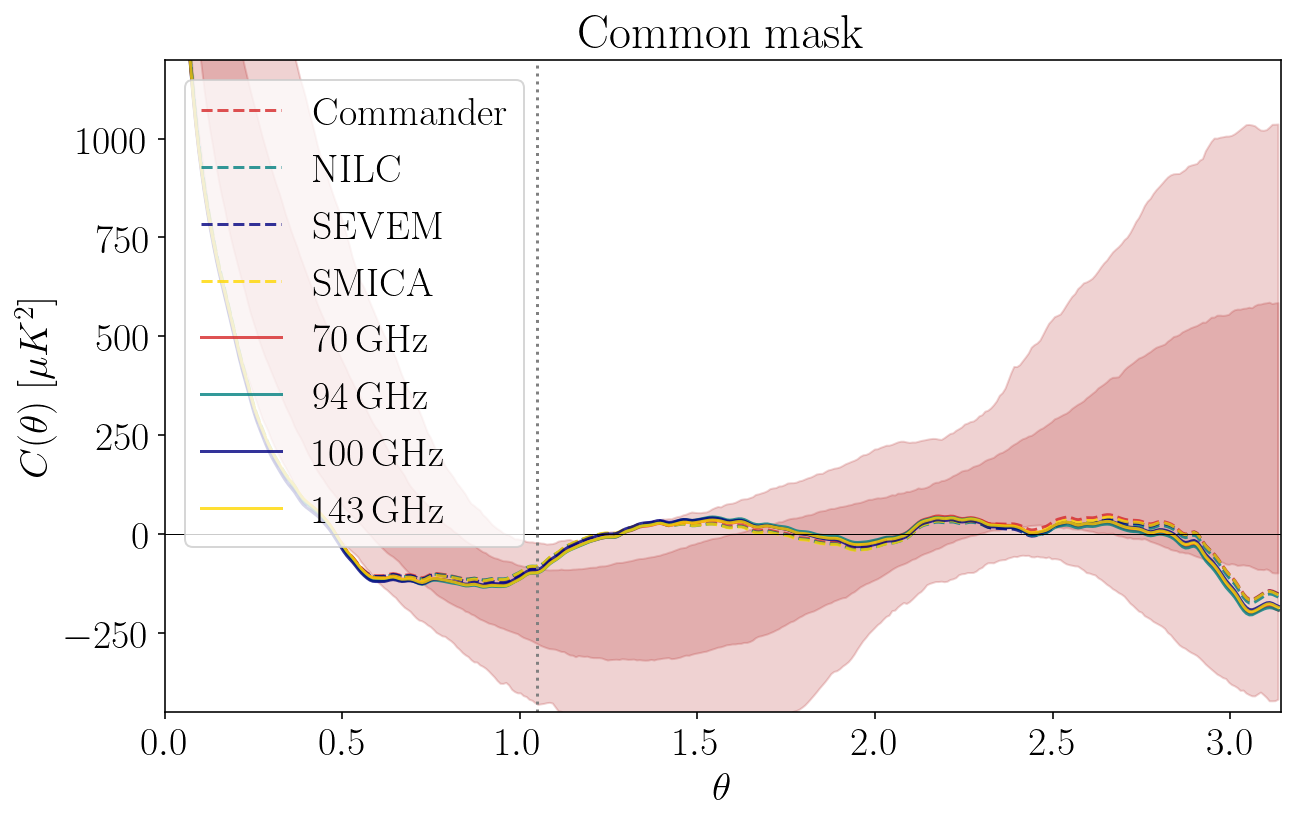

In [11]:
for m in range(Nmasks):
    fig = plt.figure(figsize=(10, 6))
    for n in range(Nmaps): plt.plot(theta, corr_Planck[m][n], label=labels_Planck[n], ls=lss_Planck[n], color=colors_Planck[n], alpha=0.8)
    plt.fill_between(theta, perc_68_lower[m], perc_68_upper[m], alpha= 0.2, color=colors_mask[m])
    plt.fill_between(theta, perc_95_lower[m], perc_95_upper[m], alpha= 0.2, color=colors_mask[m])
    plt.title(labels_mask[m])
    plt.ylim(-450, 1200)
    plt.xlim(0, np.pi)
    plt.xlabel(r"$\theta$")
    plt.ylabel(r"$C(\theta)\ [\mu K^2]$")
    plt.axhline(0, color="black", lw=0.5)
    plt.axvline(60/180*np.pi, color="grey", ls=":")
    plt.legend()
    #plt.savefig(f"corr_{names_mask[m]}.pdf", format="PDF")
    plt.show()

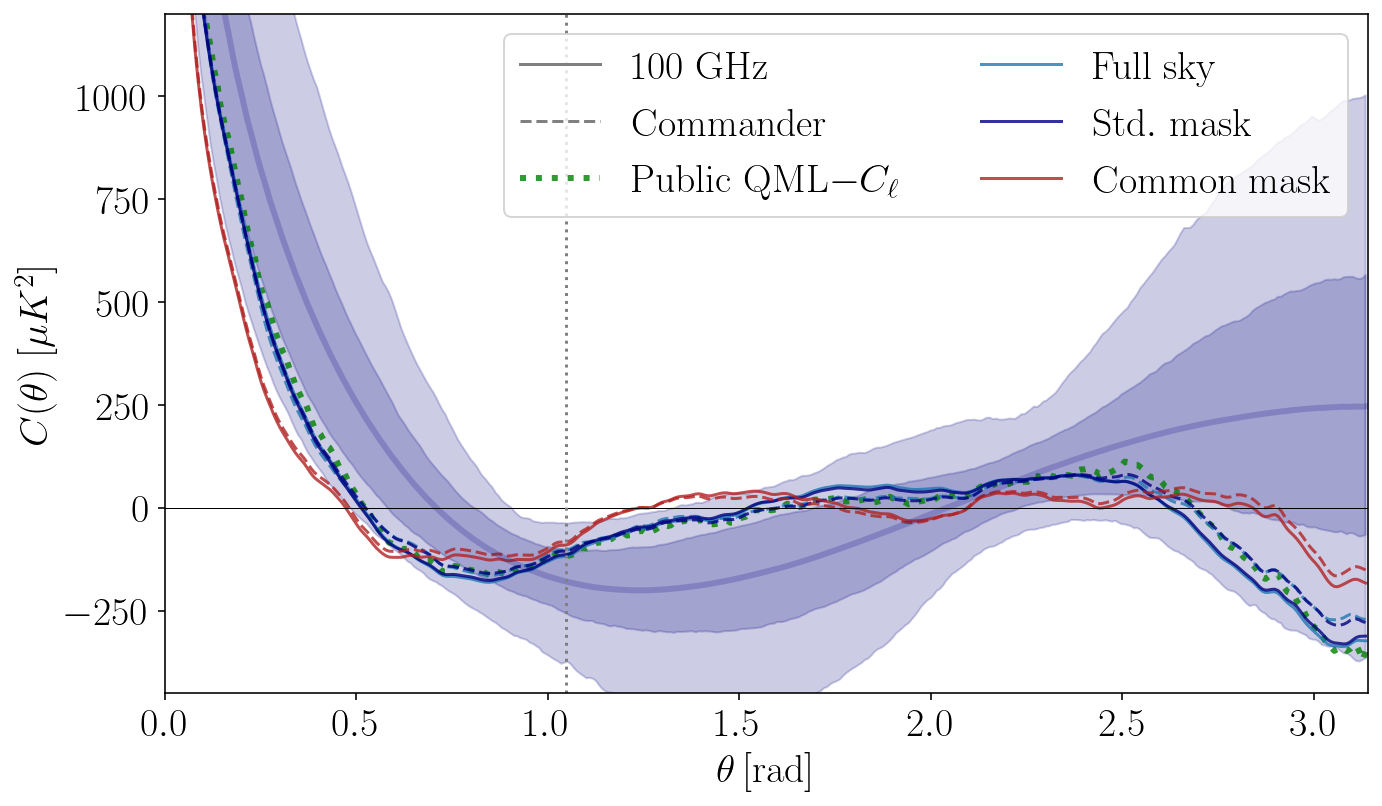

In [12]:
fig = plt.figure(figsize=(10, 6))
plt.plot([0], [0], color='grey', ls="-", label=r'$100\ \mathrm{GHz}$')
plt.plot([0], [0], color='grey', ls="--", label=r'$\mathrm{Commander}$')
plt.plot(theta, corr_qml, color=color_qml, alpha=0.8, ls=":", lw=3, label=label_qml)

for m in range(Nmasks):
    plt.plot(theta, corr_Planck[m][index_Hayley], color=colors_mask[m], alpha=0.8, ls="-", label=labels_mask[m])
    plt.plot(theta, corr_Planck[m][index_Planck], color=colors_mask[m], alpha=0.8, ls="--")
m = 1
plt.fill_between(theta, perc_68_lower[m], perc_68_upper[m], alpha= 0.2, color=colors_mask[m])
plt.fill_between(theta, perc_95_lower[m], perc_95_upper[m], alpha= 0.2, color=colors_mask[m])
#plt.plot(theta, corr_theory, color=colors_mask[m], ls="-", alpha=0.2, lw=3)
plt.plot(theta, mean_corrs[m], color=colors_mask[m], ls="-", alpha=0.2, lw=3)
plt.ylim(-450, 1200)
plt.xlim(0, np.pi)
plt.xlabel(r"$\theta\,\mathrm{[rad]}$")
plt.ylabel(r"$C(\theta)\ [\mu K^2]$")
plt.axhline(0, color="black", lw=0.5)
plt.axvline(60/180*np.pi, color="grey", ls=":")
plt.legend(loc="upper right", ncol=2)
plt.tight_layout()
#plt.savefig("Corr_fct.pdf", format="PDF")
plt.show()

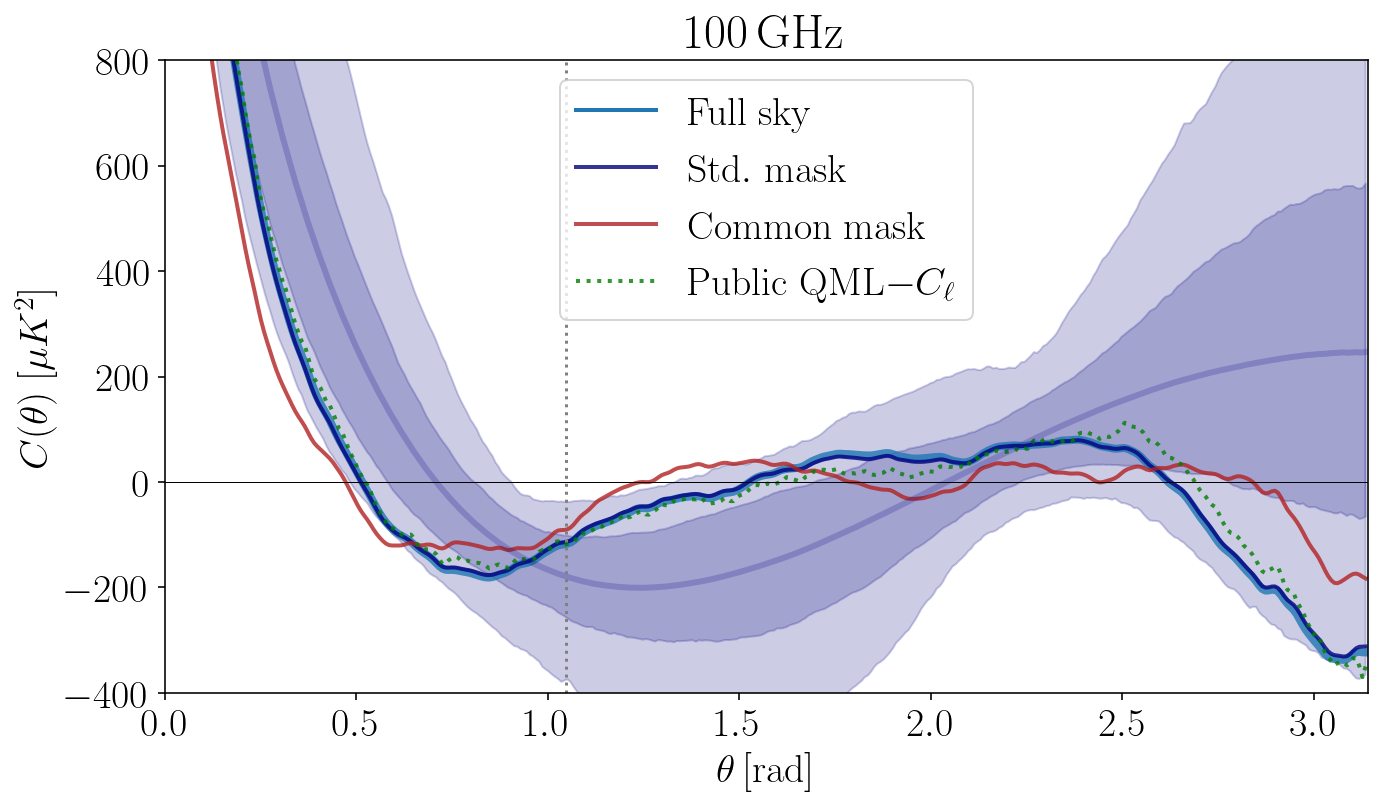

In [13]:
fig = plt.figure(figsize=(10, 6))
plt.title(labels_Planck[index_Hayley])
m = 0
plt.plot([0], [0], color=colors_mask[m], ls="-", label=labels_mask[m], lw=2)
plt.plot(theta, corr_Planck[m][index_Hayley], color=colors_mask[m], alpha=0.8, ls="-", lw=4)
m = 1
plt.plot(theta, corr_Planck[m][index_Hayley], color=colors_mask[m], alpha=0.8, ls="-", label=labels_mask[m], lw=2)
m = 2
plt.plot(theta, corr_Planck[m][index_Hayley], color=colors_mask[m], alpha=0.8, ls="-", label=labels_mask[m], lw=2)
m = 1
plt.fill_between(theta, perc_68_lower[m], perc_68_upper[m], alpha= 0.2, color=colors_mask[m])
plt.fill_between(theta, perc_95_lower[m], perc_95_upper[m], alpha= 0.2, color=colors_mask[m])
plt.plot(theta, corr_qml, color=color_qml, alpha=0.8, ls=":", lw=2, label=label_qml)
plt.plot(theta, mean_corrs[m], color=colors_mask[m], ls="-", alpha=0.2, lw=3)
plt.ylim(-400, 800)
plt.xlim(0, np.pi)
plt.xlabel(r"$\theta\,\mathrm{[rad]}$")
plt.ylabel(r"$C(\theta)\ [\mu K^2]$")
plt.axhline(0, color="black", lw=0.5)
plt.axvline(60/180*np.pi, color="grey", ls=":")
plt.legend(loc="upper center")
plt.tight_layout()
plt.savefig("corr_fct.pdf", format="PDF")
plt.show()

## Compute $S_{1/2}$

In [68]:
if load_stats_from_cluster: Smu_sims = [np.loadtxt(stats_dir+f"Smu_sims_{names_mask[m]}_Nsims_{Nsims}.npy") for m in range(Nmasks)]
else:                       
    Smu_sims = np.array([[CMBanom.S_mu_many(corrs[m], cos_theta, mu, method) for mu in mus] for m in range(Nmasks)])
    std_Smu_sims  = np.std(Smu_sims, axis=2)
    mean_Smu_sims = np.mean(Smu_sims, axis=2)
    perc_68_lower_Smu = np.percentile(Smu_sims, (100-68.27)/2, axis=2)
    perc_68_upper_Smu = np.percentile(Smu_sims, 68.27+(100-68.27)/2, axis=2)
    perc_95_lower_Smu = np.percentile(Smu_sims, (100-95.45)/2, axis=2)
    perc_95_upper_Smu = np.percentile(Smu_sims, 95.45+(100-95.45)/2, axis=2)

In [69]:
Smu_Planck = np.array([[[CMBanom.S_mu(corr_Planck[m][n], cos_theta, mu, method) for mu in mus] for n in range(Nmaps)] for m in range(Nmasks)])
Smu_Planck_QML = np.array([CMBanom.S_mu_many([corr_qml], cos_theta, mu) for mu in mus])

In [70]:
std_Smu_sims

array([[ 21492.31858801,  31836.1171026 ,  35613.06793954,
         36465.00941401,  36501.93566973,  37341.38856632,
         39730.19744626,  43687.76618534,  49872.92206053,
         56865.1078502 ,  64283.62559063,  71865.5659571 ,
         77803.59055418,  82471.10769579,  85160.70878409,
         85873.68851222,  85756.19997172,  87641.94674554,
         98322.59952494, 144085.92934867],
       [ 21440.98898558,  31763.11191018,  35526.10593086,
         36371.27837902,  36408.61555343,  37244.70679656,
         39626.31859798,  43574.26184778,  49746.81716874,
         56717.18227108,  64109.96991964,  71670.42471771,
         77597.13150357,  82253.52399471,  84940.99087376,
         85658.88909204,  85545.68383433,  87426.08242921,
         98090.13954887, 143764.65593286],
       [ 25595.72907235,  38766.9632792 ,  43742.49200453,
         44911.09739018,  45047.99202597,  46227.97160966,
         49331.20761728,  54370.35436575,  62148.76022471,
         70884.62813295,  801

In [65]:
std_Smu_sims[m]

array([ 25595.72907235,  38766.9632792 ,  43742.49200453,  44911.09739018,
        45047.99202597,  46227.97160966,  49331.20761728,  54370.35436575,
        62148.76022471,  70884.62813295,  80168.151147  ,  89647.3928623 ,
        96893.83785323, 102465.23336301, 105580.30027137, 106476.67343106,
       106704.68805447, 109526.61635527, 122786.03891845, 172480.01524754])

## Plot $S_{1/2}$

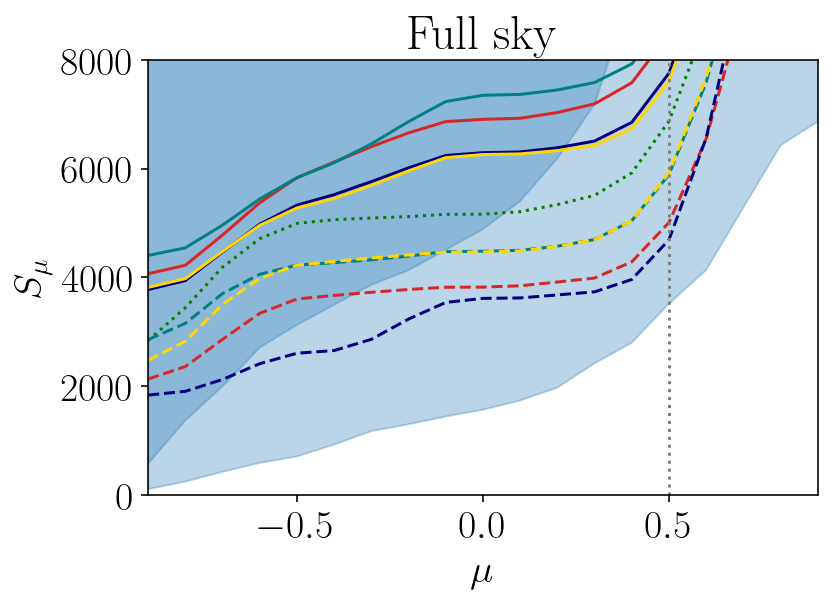

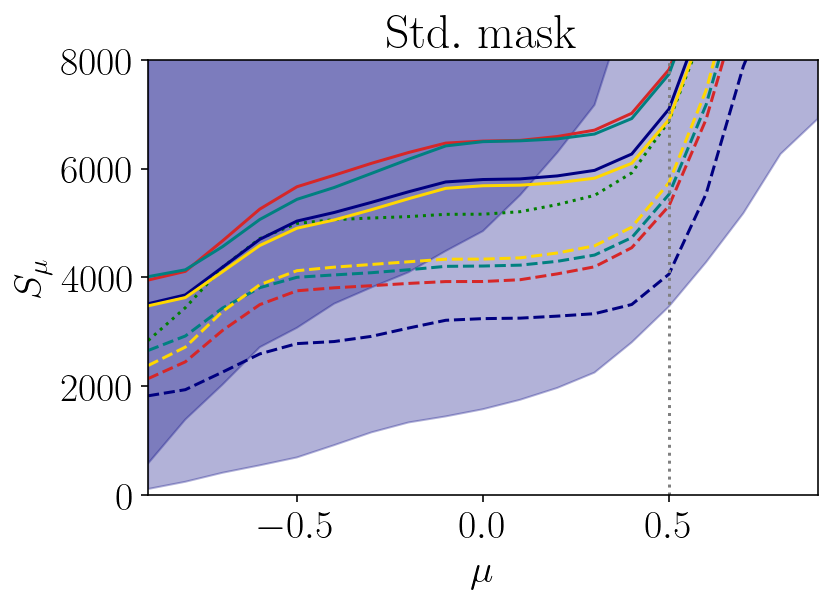

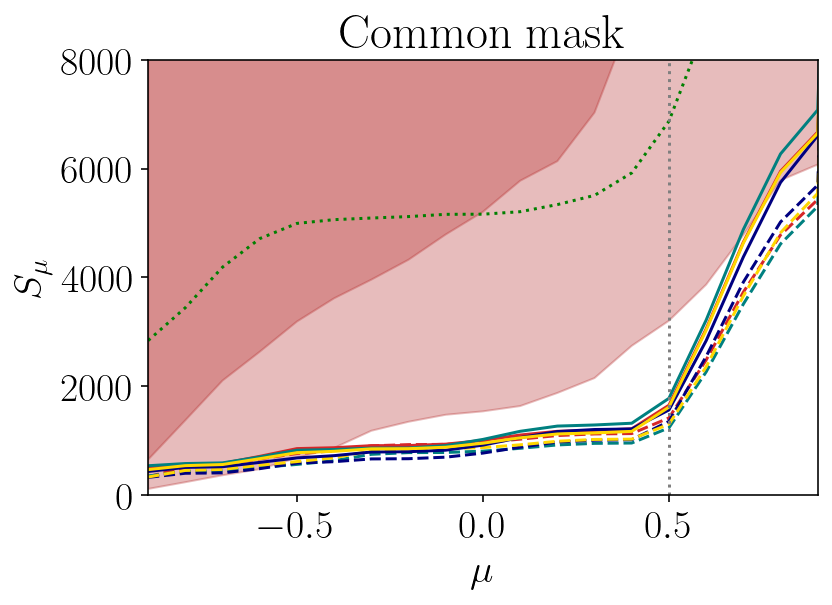

In [85]:
for m in range(Nmasks):
    plt.title(labels_mask[m])
    plt.plot(mus, Smu_Planck_QML, label=label_qml, color=color_qml, ls=":")
    for n in range(Nmaps): plt.plot(mus, Smu_Planck[m][n], label=labels_Planck[n], color=colors_Planck[n], ls=lss_Planck[n])
#    plt.plot(mus, mean_Smu_sims[m])
#     plt.plot(mus, perc_68_lower_Smu[m])
#     plt.plot(mus, perc_68_upper_Smu[m])
    plt.fill_between(mus, perc_68_lower_Smu[m], perc_68_upper_Smu[m], color=colors_mask[m], alpha=0.3)
    plt.fill_between(mus, perc_95_lower_Smu[m], perc_95_upper_Smu[m], color=colors_mask[m], alpha=0.3)
    #plt.fill_between(mus, mean_Smu_sims[m]-2*std_Smu_sims[m], mean_Smu_sims[m]+2*std_Smu_sims[m], color=colors_mask[m], alpha=0.3)
    
    plt.axvline(0.5, color="grey", ls=":")
    plt.xlabel(r"$\mu$")
    plt.ylabel(r"$S_\mu$")
    plt.xlim(-0.9,0.9)
    plt.ylim(0,8000)
    #plt.axvline(27, color="grey", ls=":")
    #plt.legend(loc="lower right")
    plt.show()

In [57]:
Smu_Planck

array([[[ 2130.52421141,  2359.96203932,  2860.11927249,  3339.34251718,
          3602.69728545,  3668.58700374,  3726.14207932,  3777.56175549,
          3819.24762063,  3821.58905225,  3845.51145062,  3914.96446031,
          3987.66159053,  4286.18839443,  5008.88932839,  6549.57700452,
          9014.41722803, 10683.7898746 , 10999.19817143, 44569.50094131],
        [ 2856.36203977,  3154.43171642,  3702.27283125,  4057.36802991,
          4225.8906815 ,  4270.99406223,  4323.64779049,  4392.0527134 ,
          4473.85249003,  4481.14355704,  4498.52663846,  4573.76295235,
          4695.69643293,  5040.81320987,  5891.95321319,  7586.73173617,
         10082.18250651, 11862.94185873, 12304.97110467, 49507.53205592],
        [ 1834.99724739,  1904.3117787 ,  2122.30144542,  2412.71017984,
          2605.28900741,  2654.2636558 ,  2860.81496982,  3233.32841236,
          3539.42535329,  3613.98276861,  3622.64182557,  3677.5705867 ,
          3734.14839232,  3961.62966883,  4690.01

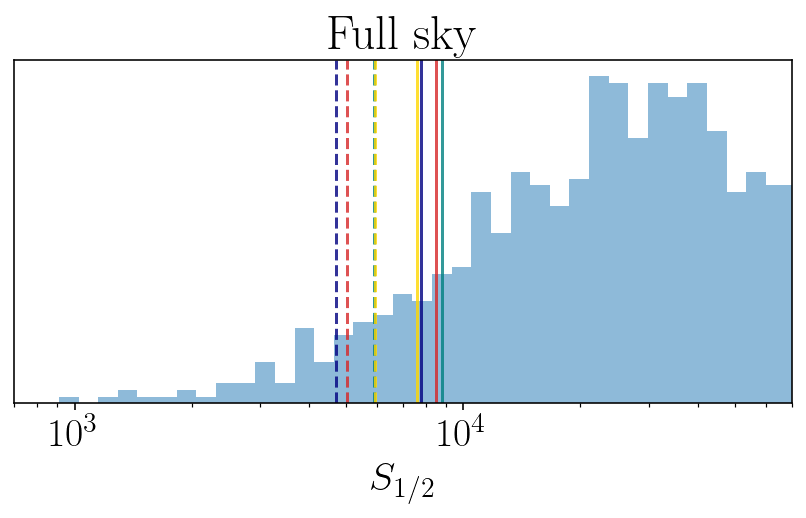

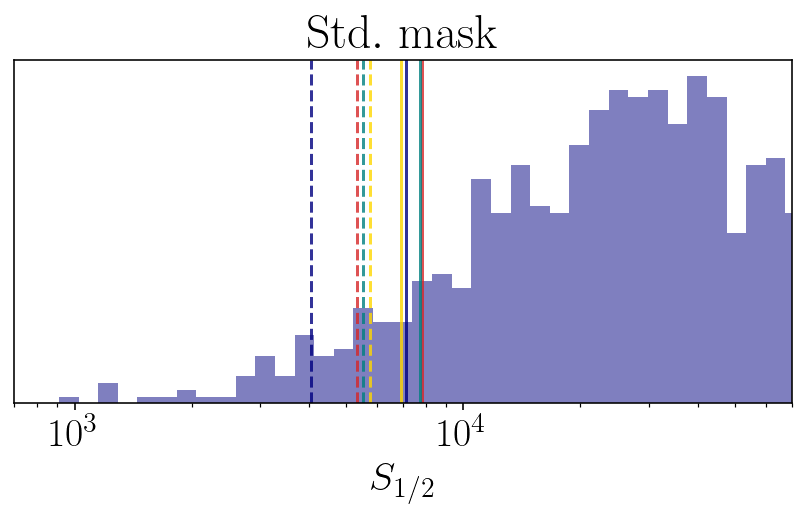

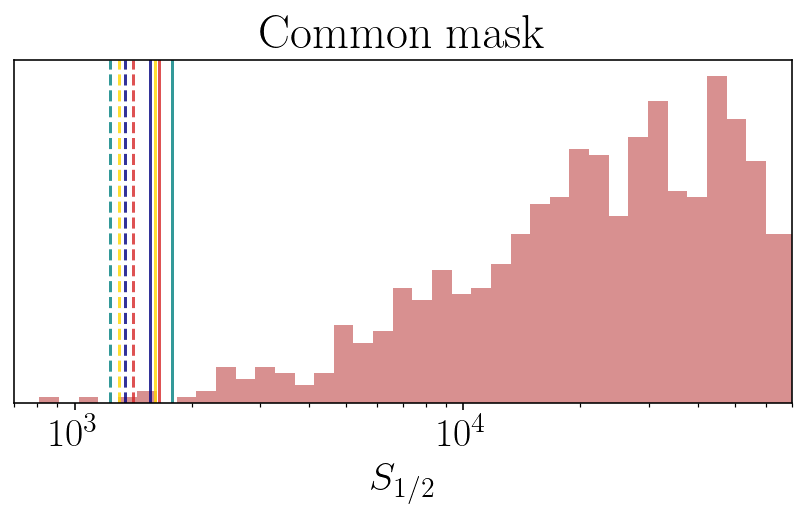

In [33]:
for m in range(Nmasks):
    bins = 10**np.linspace(2, 7, 100)
    h=plt.hist(Smu_sims[m][mu_index], bins=bins, color=colors_mask[m], alpha=0.5)
    
    for n in range(Nmaps): plt.axvline(Smu_Planck[m][n][mu_index], color=colors_Planck[n], ls=lss_Planck[n], label=labels_Planck[n], alpha=0.8)
    
    plt.title(labels_mask[m])
    plt.xlim(7e2, 7e4)
    plt.xscale("log")
    plt.tick_params(axis='y', which='both', left=False, labelleft=False) 
    plt.xlabel(r"$S_{1/2}$")
    #plt.legend(loc="lower right")
    plt.tight_layout()
    
    #if m==1: plt.legend(loc='center right', bbox_to_anchor=(2.8, 0.5), ncol=4)
    plt.savefig("hist_S_12_"+names_mask[m]+".pdf")
    plt.show()

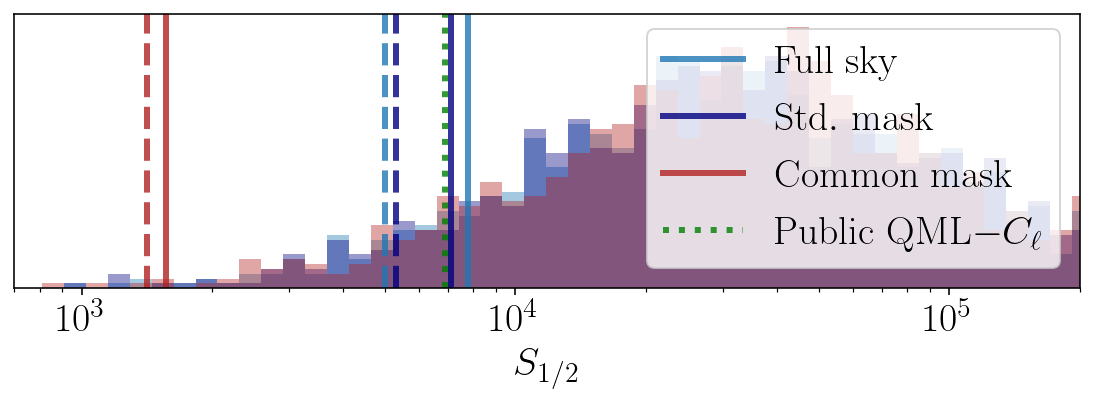

In [35]:
fig = plt.figure(figsize=(8, 3.2))
bins = 10**np.linspace(2, 7, 100)
#plt.plot([0], [0], color='grey', ls="-", lw=3, label=labels_Planck[index_Hayley])
#plt.plot([0], [0], color='grey', ls="--", lw=3, label=labels_Planck[index_Planck])
for m in range(Nmasks):
    h=plt.hist(Smu_sims[m][mu_index], bins=bins, color=colors_mask[m], alpha=0.4)
    plt.axvline(Smu_Planck[m][index_Hayley][mu_index], color=colors_mask[m], lw=3, alpha=0.8, ls="-", label=labels_mask[m])
    plt.axvline(Smu_Planck[m][index_Planck][mu_index], color=colors_mask[m], lw=3, alpha=0.8, ls="--")
plt.axvline(Smu_Planck_QML[mu_index], color=color_qml, lw=3, alpha=0.8, ls=":", label=label_qml)
plt.xlim(7e2, 2e5)
plt.xscale("log")
plt.tick_params(axis='y', which='both', left=False, labelleft=False) 
plt.xlabel(r"$S_{1/2}$")
#plt.legend(loc='center right', bbox_to_anchor=(2.8, 0.5), ncol=1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("hist_S_12.pdf", format="PDF")
plt.show()

# Compute p-values (in %)

In [ ]:
print("-----------")
for m in range(Nmasks):
    print(names_mask[m])
    print("-----------")
    for n in range(Nmaps): print(f"{Smu_Planck[m][n]:.0f}, p = {100*CMBanom.pval_lower(Smu_Planck[m][n], Smu_sims[m]):.2f}% ({names_Planck[n]})")
    print("-----------")

In [ ]:
print("p-values")
for m in range(Nmasks):
    print(names_mask[m],": ", end="")
    for n in range(Nmaps):
        print(f"&{100*CMBanom.pval_lower(Smu_Planck[m][n],Smu_sims[m]):.2f} ", end="")
    print("\\\\")

In [ ]:
print("stats")
for m in range(Nmasks):
    print(names_mask[m],": ", end="")
    for n in range(Nmaps):
        print(f"&{Smu_Planck[m][n]:.0f} ", end="")
    print("\\\\")